In [1]:
def askQuestion(ind, disorderOffset, disorder_scores):
    question = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    question[disorderOffset] = big_array[ind_outer][disorderOffset][ind-1]
    disorder_scores[disorderOffset] += question[disorderOffset]
    return question

In [2]:
anxiety_threshold = [10,9,8,6,5,3,2]
depression_threshold = [10,10,9,8,7,6,4,3,2]
stress_threshold = [23,20,17,16,15,14,12,9,6,3]

In [3]:
import pandas as pd

# Load the 100-row subset CSVs
anxiety_df = pd.read_csv("anxiety_subset.csv")
depression_df = pd.read_csv("depression_subset.csv")
stress_df = pd.read_csv("stress_subset.csv")

assert len(anxiety_df) == len(depression_df) == len(stress_df) == 100, \
    "All CSVs must have exactly 100 rows"

# Put data into big_array
big_array = []

for i in range(len(anxiety_df)):
    anxiety_scores = anxiety_df.iloc[i, 7:-2].astype(int).tolist()
    depression_scores = depression_df.iloc[i, 7:-2].astype(int).tolist()
    stress_scores = stress_df.iloc[i, 7:-2].astype(int).tolist()
    
    big_array.append([anxiety_scores, depression_scores, stress_scores])

print("Total samples in big_array:", len(big_array))
print("Top sample in big_array:", big_array[1])

Total samples in big_array: 100
Top sample in big_array: [[0, 0, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 2, 2, 0, 2, 2, 2, 2, 2, 2]]


In [4]:
anxiety_values = []
depression_values = []
stress_values = []
normal_anxiety_values = []
normal_depression_values = []
normal_stress_values = []

In [5]:
from gym import Env
from gym.spaces import Discrete, MultiDiscrete
import numpy as np
import random

In [6]:
ind_outer = 0

In [7]:
class ChatBotEnv(Env):
  def __init__(self):
    self.action_space = Discrete(4)
    self.observation_space = MultiDiscrete([4,4,5,4])
    self.state = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    self.anxiety_question_offset = 7
    self.depression_question_offset = 9
    self.stress_question_offset = 10
    self.anxiety_score = 0
    self.depression_score = 0
    self.stress_score = 0
    self.anxiety_predicted = False
    self.depression_predicted = False
    self.stress_predicted = False
    self.disorder_scores = [0,0,0]

  def step(self, action):
    done = False
      
    # Ask Anxiety
    if action == 0:
        if self.anxiety_question_offset == -1:
            reward = -5
        elif self.anxiety_question_offset == 0 and self.anxiety_score >= anxiety_threshold[0]:
            self.anxiety_predicted = True
            self.anxiety_question_offset = -1
            reward = 10
        elif self.anxiety_question_offset == 7 or self.anxiety_score >= anxiety_threshold[self.anxiety_question_offset]:
            self.state = askQuestion(self.anxiety_question_offset, 0, self.disorder_scores)
            self.anxiety_question_offset -= 1;
            self.anxiety_score += self.state[0]
            reward = -1
        else:
            reward = -5
    # Ask Depression
    if action == 1:
        if self.depression_question_offset == -1:
            reward = -5
        elif self.depression_question_offset == 0 and self.depression_score >= depression_threshold[0]:
            self.depression_predicted = True
            self.depression_question_offset = -1
            reward = 10
        elif self.depression_question_offset == 9 or self.depression_score >= depression_threshold[self.depression_question_offset]:
            self.state = askQuestion(self.depression_question_offset, 1, self.disorder_scores)
            self.depression_question_offset -= 1;
            self.depression_score += self.state[1]
            reward = -1
        else:
            reward = -5
    # Ask Stress
    if action == 2:
        if self.stress_question_offset == -1:
            reward = -5
        elif self.stress_question_offset == 0 and self.stress_score >= stress_threshold[0]:
            self.stress_predicted = True
            self.stress_question_offset = -1
            reward = 10
        elif self.stress_question_offset == 10 or self.stress_score >= stress_threshold[self.stress_question_offset]:
            self.state = askQuestion(self.stress_question_offset, 2,self.disorder_scores)
            self.stress_question_offset -= 1;
            self.stress_score += self.state[2]
            reward = -1
        else:
            reward = -5
    else:
        good_to_go = True
        if not self.anxiety_predicted:
            if self.anxiety_question_offset == 7:
                reward = -5
                good_to_go = False
            elif self.anxiety_score >= anxiety_threshold[self.anxiety_question_offset]:
                reward = -5
                good_to_go = False
        if not self.depression_predicted:
            if self.depression_question_offset == 9:
                reward = -5
                good_to_go = False
            elif self.depression_score >= depression_threshold[self.depression_question_offset]:
                reward = -5
                good_to_go = False
        if not self.stress_predicted:
            if self.stress_question_offset == 10:
                reward = -5
                good_to_go = False
            elif self.stress_score >= stress_threshold[self.stress_question_offset]:
                reward = -5
                good_to_go = False
        if good_to_go:
            done = True
            if self.anxiety_predicted:
                anxiety_values.append(self.disorder_scores[0])
                print("Anxiety")
            if self.depression_predicted:
                depression_values.append(self.disorder_scores[1])
                print("Depression")
            if self.stress_predicted:
                stress_values.append(self.disorder_scores[2])
                print("Stress")
            if not self.anxiety_predicted and not self.depression_predicted and not self.stress_predicted:
                normal_anxiety_values.append(self.disorder_scores[0])
                normal_depression_values.append(self.disorder_scores[1])
                normal_stress_values.append(self.disorder_scores[2])
                print("Normal")
            reward = 20

            global ind_outer
            ind_outer += 1
            
    info = {}
        
    return self.state, reward, done, info

  def render(self):
    pass

  def reset(self):
    self.disorder_scores = [0,0,0]
    self.state = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    self.anxiety_question_offset = 7
    self.depression_question_offset = 9
    self.stress_question_offset = 10
    self.anxiety_score = 0
    self.depression_score = 0
    self.stress_score = 0
    self.anxiety_predicted = False
    self.depression_predicted = False
    self.stress_predicted = False
      
    return self.state

In [8]:
env = ChatBotEnv()

In [10]:
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines.common.policies import MlpLstmPolicy

In [11]:
import os

In [12]:
path = os.path.join("Training_Final","Recurrent_Model_Final")

In [13]:
rl_model = RecurrentPPO.load(path,env)

C:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [14]:
device = "cpu"

Anxiety
Depression
Normal
Anxiety
Depression
Anxiety
Stress
Normal
Anxiety
Depression
Anxiety
Depression
Normal
Anxiety
Depression
Normal
Normal
Anxiety
Depression
Normal
Normal
Normal
Anxiety
Depression
Anxiety
Depression
Normal
Anxiety
Depression
Stress
Anxiety
Depression
Normal
Normal
Normal
Anxiety
Depression
Stress
Normal
Normal
Normal
Normal
Anxiety
Depression
Normal
Normal
Normal
Normal
Anxiety
Depression
Anxiety
Depression
Depression
Normal
Normal
Anxiety
Depression
Anxiety
Depression
Normal
Normal
Anxiety
Anxiety
Anxiety
Normal
Normal
Normal
Anxiety
Anxiety
Depression
Normal
Anxiety
Depression
Normal
Normal
Normal
Normal
Normal
Depression
Anxiety
Normal
Depression
Anxiety
Depression
Stress
Anxiety
Depression
Anxiety
Normal
Normal
Anxiety
Depression
Stress
Normal
Anxiety
Depression
Stress
Normal
Anxiety
Depression
Stress
Normal
Anxiety
Depression
Stress
Anxiety
Depression
Anxiety
Normal
Normal
Anxiety
Depression
Normal
Anxiety
Depression
Depression
Anxiety
Depression
Anxiety
De

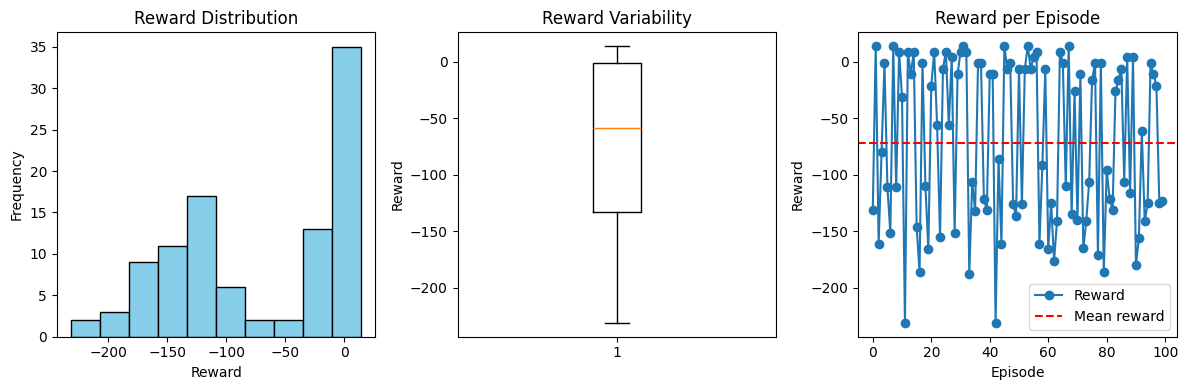

Mean reward: -71.34
Std reward: 72.26
Mean episode length: 21.23


In [15]:
import gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO  # change to your algo

# Evaluation parameters
n_eval_episodes = 100
episode_rewards = []
episode_lengths = []

for ep in range(n_eval_episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    length = 0
    
    while not done:
        action, _ = rl_model.predict(obs)
        obs, reward, done, info = env.step(action)
        total_reward += reward
        length += 1
    
    episode_rewards.append(total_reward)
    episode_lengths.append(length)

# Convert to numpy for easier math
episode_rewards = np.array(episode_rewards)
episode_lengths = np.array(episode_lengths)

# ---------------- PLOTS ----------------

# 1. Histogram of rewards
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(episode_rewards, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.title('Reward Distribution')

# 2. Boxplot of rewards
plt.subplot(1,3,2)
plt.boxplot(episode_rewards, vert=True)
plt.ylabel('Reward')
plt.title('Reward Variability')

# 3. Reward per episode
plt.subplot(1,3,3)
plt.plot(episode_rewards, marker='o', label='Reward')
plt.axhline(np.mean(episode_rewards), color='red', linestyle='--', label='Mean reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward per Episode')
plt.legend()

plt.tight_layout()
plt.show()

# Print stats
print(f"Mean reward: {np.mean(episode_rewards):.2f}")
print(f"Std reward: {np.std(episode_rewards):.2f}")
print(f"Mean episode length: {np.mean(episode_lengths):.2f}")

In [16]:
print(anxiety_values)
print(depression_values)
print(stress_values)
print(ind_outer)

[14, 21, 14, 12, 15, 14, 11, 14, 14, 21, 14, 21, 14, 21, 21, 14, 20, 14, 13, 12, 14, 12, 19, 11, 21, 13, 11, 21, 21, 21, 21, 12, 15, 12, 21, 13, 10, 14, 14, 21, 17, 21, 21, 12]
[21, 27, 14, 19, 15, 17, 18, 21, 27, 24, 27, 18, 25, 27, 18, 23, 27, 18, 27, 17, 15, 27, 18, 27, 27, 26, 26, 16, 17, 26, 19, 17, 17, 24, 27, 14, 27, 27, 18]
[27, 40, 40, 40, 38, 40, 33, 28, 29, 40, 40]
100


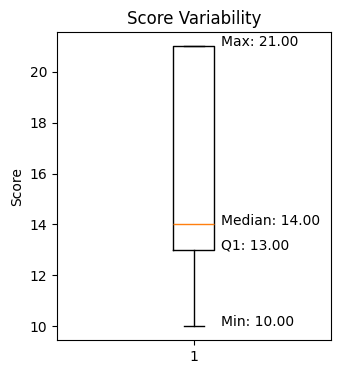

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,2)

# Create boxplot and capture stats
box = plt.boxplot(anxiety_values, vert=True)

# Compute statistics
min_val = np.min(anxiety_values)
q1 = np.percentile(anxiety_values, 25)
median = np.median(anxiety_values)
q3 = np.percentile(anxiety_values, 75)
max_val = np.max(anxiety_values)
mean_val = np.mean(anxiety_values)

plt.ylabel('Score')
plt.title('Score Variability')

# Add text annotations on plot
plt.text(1.1, min_val, f'Min: {min_val:.2f}')
plt.text(1.1, q1, f'Q1: {q1:.2f}')
plt.text(1.1, median, f'Median: {median:.2f}')
plt.text(1.1, max_val, f'Max: {max_val:.2f}')

plt.show()

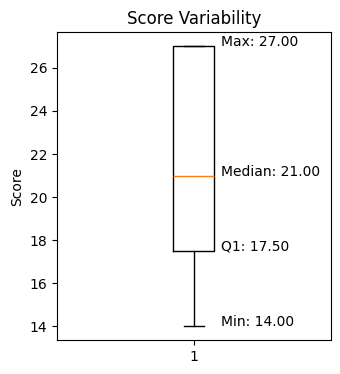

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,2)

# Create boxplot and capture stats
box = plt.boxplot(depression_values, vert=True)

# Compute statistics
min_val = np.min(depression_values)
q1 = np.percentile(depression_values, 25)
median = np.median(depression_values)
q3 = np.percentile(depression_values, 75)
max_val = np.max(depression_values)
mean_val = np.mean(depression_values)

plt.ylabel('Score')
plt.title('Score Variability')

# Add text annotations on plot
plt.text(1.1, min_val, f'Min: {min_val:.2f}')
plt.text(1.1, q1, f'Q1: {q1:.2f}')
plt.text(1.1, median, f'Median: {median:.2f}')
plt.text(1.1, max_val, f'Max: {max_val:.2f}')

plt.show()

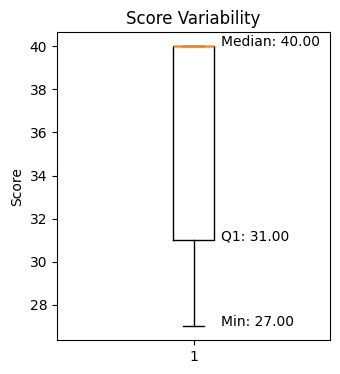

In [20]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,2)

# Create boxplot and capture stats
box = plt.boxplot(stress_values, vert=True)

# Compute statistics
min_val = np.min(stress_values)
q1 = np.percentile(stress_values, 25)
median = np.median(stress_values)
q3 = np.percentile(stress_values, 75)
max_val = np.max(stress_values)
mean_val = np.mean(stress_values)

plt.ylabel('Score')
plt.title('Score Variability')

# Add text annotations on plot
plt.text(1.1, min_val, f'Min: {min_val:.2f}')
plt.text(1.1, q1, f'Q1: {q1:.2f}')
plt.text(1.1, median, f'Median: {median:.2f}')

plt.show()